# Bias correction of CMIP6 and DestinE forcing against ERA5

This notebook applies statistical bias correction to CMIP6 and DestinE future forcing data, using ERA5 as the observational reference. The model was calibrated on ERA5, so systematic differences between ERA5 and CMIP6/DestinE will propagate into discharge projections unless corrected.

**Approach:**
- **Reference (obs):** ERA5 over the calibration period
- **Simulated historical (simh):** CMIP6 historical / DestinE historical run over the same period
- **Simulated future (simp):** CMIP6 future scenarios / DestinE SSP3-7.0 future run to be corrected

Bias correction is applied per variable using [python-cmethods](https://python-cmethods.readthedocs.io/en/stable/introduction.html):
- `pr` (precipitation): **Quantile Delta Mapping**, multiplicative (`kind='*'`) — preserves future trends in extremes
- `tas` (2m temperature): **Quantile Delta Mapping**, additive (`kind='+'`)
- `rsds` (surface radiation): **Quantile Delta Mapping**, multiplicative (`kind='*'`)

After correction, `evspsblpot` is re-derived via the Makkink method so that it is internally consistent with the corrected meteorology. The bias-corrected forcing is saved to a `bias_corrected/` subdirectory and is ready for use in [step_3b](step_3b_model_run_future.ipynb).

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import sys
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
import shutil
import yaml
from datetime import datetime

# Niceties
from rich import print

# DestinE forcing (Makkink evspsblpot derivation + load methods)
try:
    from scripts.forcing_destine import DestinEForcing, DestinEHistoricalForcing, DestinEFutureForcing
except ImportError:
    project_root = Path().resolve().parent
    sys.path.append(str(project_root))
    from scripts.forcing_destine import DestinEForcing, DestinEHistoricalForcing, DestinEFutureForcing

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [3]:
# Bias correction library
from cmethods import adjust

In [29]:
# Parameters — these get changed when running on HPC
settings_path = "settings.json"

In [30]:
# Load settings
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

display(settings)

{'caravan_id': 'camelsaus_102101A',
 'country': 'australia',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2049-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'koppen_raster_path': '/data/shared/climate-data/koppen_geiger/1991_2020/koppen_geiger_0p00833333.tif',
 'base_path': '/home/mmelotto/ewatercycleClimateImpact/HBV',
 'path_caravan': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/caravan',
 'path_ERA5': '/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5',
 'path_DestinE': '/home/mmelotto/ewatercycleClimateImpa

## Load ERA5 forcing (reference)

ERA5 is the observational reference on which the HBV model was calibrated. It defines the "true" distribution that CMIP6 and DestinE should be corrected towards.

In [6]:
# ERA5 forcing is stored in a sub-directory created by eWaterCycle / ESMValTool
load_location = Path(settings['path_ERA5']) / "work" / "diagnostic" / "script" 
ERA5_forcing_object = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

display(ERA5_forcing_object)

LumpedMakkinkForcing(start_time='1994-08-01T00:00:00Z', end_time='2014-07-31T00:00:00Z', directory=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script'), shape=PosixPath('/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/ERA5/work/diagnostic/script/camelsaus_102101A.shp'), filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_1994-2014.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_1994-2014.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1994-2014.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

In [7]:
# Load each variable separately
ds_pr = xr.open_dataset(ERA5_forcing_object['pr'])
ds_tas = xr.open_dataset(ERA5_forcing_object['tas'])
ds_rsds = xr.open_dataset(ERA5_forcing_object['rsds'])

# Shift tas time by 30 minutes to align with the others (11:30 → 12:00)
ds_tas['time'] = ds_tas['time'] + pd.Timedelta(minutes=30)

# Merge with compat='override' to ignore conflicting time_bnds
ds_era5 = xr.merge([ds_pr, ds_tas, ds_rsds], compat='override')

# Slice to calibration period
cal_start = pd.to_datetime(settings['calibration_start_date']).tz_localize(None)
cal_end = pd.to_datetime(settings['calibration_end_date']).tz_localize(None)
ds_era5_cal = ds_era5.sel(time=slice(cal_start, cal_end))

print(f"ERA5 calibration window: {cal_start} → {cal_end}")
print(f"Number of timesteps: {len(ds_era5_cal.time)}")

ERA5 calibration window: 1994-08-01 00:00:00 → 2004-07-31 00:00:00

Number of timesteps: 3652

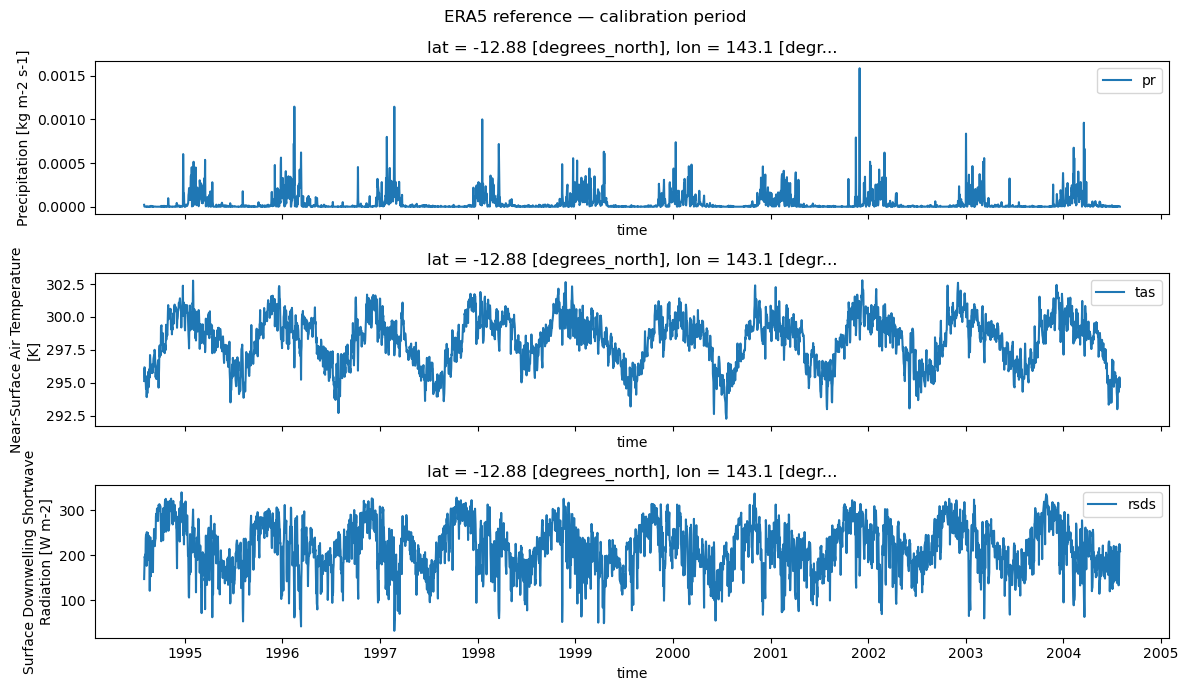

In [8]:
# Quick overview plot
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
ds_era5_cal['pr'].plot(ax=axes[0], label='pr')
ds_era5_cal['tas'].plot(ax=axes[1], label='tas')
ds_era5_cal['rsds'].plot(ax=axes[2], label='rsds')
for ax in axes:
    ax.legend()
fig.suptitle('ERA5 reference — calibration period')
plt.tight_layout()

## Bias correction configuration

We use **Quantile Delta Mapping (QDM)** from [python-cmethods](https://python-cmethods.readthedocs.io/en/stable/introduction.html). QDM corrects the quantile distribution of simulated data while preserving the climate-change signal (the delta between historical and future quantiles), making it well-suited for impact studies.

| Variable | Method | `kind` | Rationale |
|---|---|---|---|
| `pr` | QDM | `*` (multiplicative) | Precipitation is bounded at 0; ratios are physically meaningful |
| `tas` | QDM | `+` (additive) | Temperature changes are expressed as absolute differences |
| `rsds` | QDM | `*` (multiplicative) | Radiation is non-negative; ratio-based correction is appropriate |

In [9]:
BC_CONFIG = {
    'pr':   {'kind': '*', 'n_quantiles': 250},
    'tas':  {'kind': '+', 'n_quantiles': 250},
    'rsds': {'kind': '*', 'n_quantiles': 250},
}
METHOD = 'quantile_delta_mapping'

In [10]:
def bias_correct_dataset(ds_obs, ds_simh, ds_simp, method=METHOD, config=BC_CONFIG):
    """
    Apply bias correction to each variable in ds_simp.

    Parameters
    ----------
    ds_obs : xr.Dataset
        Observational reference (ERA5) over the training period.
    ds_simh : xr.Dataset
        Simulated historical over the same training period.
    ds_simp : xr.Dataset
        Simulated future data to be corrected.
    method : str
        python-cmethods method name.
    config : dict
        Per-variable settings (kind, n_quantiles).

    Returns
    -------
    xr.Dataset
        Bias-corrected version of ds_simp.
    """
    corrected_vars = {}

    for var, cfg in config.items():
        if var not in ds_obs or var not in ds_simh or var not in ds_simp:
            print(f"[yellow]Skipping {var} — not present in all datasets[/yellow]")
            continue

        obs  = ds_obs[var].squeeze()
        simh = ds_simh[var].squeeze()
        simp = ds_simp[var].squeeze()

        # Normalize time coordinates to timezone-naive datetime64[ns]
        obs_time = pd.to_datetime(obs.time.values).tz_localize(None)
        simh_time = pd.to_datetime(simh.time.values).tz_localize(None)
        
        # Find common times
        common_time = np.intersect1d(obs_time, simh_time)
        
        if len(common_time) == 0:
            print(f"[red]ERROR: No overlapping times for {var}![/red]")
            continue
        
        # Select using the normalized times
        obs_aligned  = obs.sel(time=obs.time.isin(pd.DatetimeIndex(common_time)))
        simh_aligned = simh.sel(time=simh.time.isin(pd.DatetimeIndex(common_time)))

        corrected = adjust(
            obs=obs_aligned,
            simh=simh_aligned,
            simp=simp,
            method=method,
            kind=cfg['kind'],
            n_quantiles=cfg['n_quantiles'],
        )

        # cmethods.adjust() may return a Dataset; extract the DataArray
        if isinstance(corrected, xr.Dataset):
            corrected = corrected[var]

        corrected.attrs = ds_simp[var].attrs
        corrected_vars[var] = corrected

    return xr.Dataset(corrected_vars)


## CMIP6

### Load CMIP6 historical and future forcing

For each dataset/ensemble combination we load:
1. The **historical** run (used together with ERA5 to train the bias correction)
2. Each **future scenario** run (the data that will be corrected)

In [11]:
def load_cmip_forcing(settings, dataset, experiment, ensemble):
    """Load a LumpedMakkinkForcing object for one CMIP6 dataset/experiment/ensemble."""
    path = (
        Path(settings['path_CMIP6'])
        / dataset / experiment / ensemble
        / "work" / "diagnostic" / "script"
    )
    return ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=path)


def forcing_to_dataset(forcing_obj):
    """Open pr, tas, rsds from a LumpedMakkinkForcing as a single xarray Dataset."""
    return xr.open_mfdataset([forcing_obj['pr'], forcing_obj['tas'], forcing_obj['rsds']])

In [12]:
# Load CMIP6 historical — first ensemble member of the first dataset, matching HBV calibration
cmip_dataset = settings['CMIP_info']['dataset'][0]
cmip_hist_ensemble = settings['CMIP_info']['ensembles'][0]
forcing_obj = load_cmip_forcing(settings, cmip_dataset, 'historical', cmip_hist_ensemble)
ds_cmip_hist = forcing_to_dataset(forcing_obj).sel(time=slice(cal_start, cal_end))

print(f"Loaded CMIP6 historical: {cmip_dataset} / {cmip_hist_ensemble}")
display(ds_cmip_hist)

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Loaded CMIP6 historical: MPI-ESM1-2-LR / r1i1p1f1

<xarray.Dataset> Size: 132kB
Dimensions:    (time: 3652, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1994-08-01T12:00:00 ... 2004-07-30T...
    lat        float64 8B -13.06
    lon        float64 8B 143.4
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time) float32 15kB dask.array<chunksize=(3652,), meta=np.ndarray>
    time_bnds  (time, bnds) datetime64[ns] 58kB dask.array<chunksize=(3652, 2), meta=np.ndarray>
    lat_bnds   (bnds) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    lon_bnds   (bnds) float64 16B dask.array<chunksize=(2,), meta=np.ndarray>
    tas        (time) float32 15kB dask.array<chunksize=(3652,), meta=np.ndarray>
    rsds       (time) float32 15kB dask.array<chunksize=(3652,), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    cmor_version:           3.5.0
    ...                     ...
    table_info:             Creation Date:(09 May 2019) MD5:e6ef8ececc8f33864...
    title:                  MPI-ESM1-2-LR output prepared for CMIP6
    variable_id:            pr
    variant_label:          r1i1p1f1
    software:               Created with ESMValTool v2.11.1
    caption:                Forcings for generic hydrological model

In [13]:
# Load CMIP6 future for every dataset × experiment × ensemble combination
cmip_future = {}  # key: (dataset, experiment, ensemble) → xr.Dataset

for dataset in settings['CMIP_info']['dataset']:
    for experiment in settings['CMIP_info']['experiments'][1:]:  # skip 'historical'
        for ensemble in settings['CMIP_info']['ensembles']:
            key = (dataset, experiment, ensemble)
            try:
                forcing_obj = load_cmip_forcing(settings, dataset, experiment, ensemble)
                cmip_future[key] = forcing_to_dataset(forcing_obj)
                print(f"Loaded: {dataset} / {experiment} / {ensemble}")
            except FileNotFoundError:
                print(f"[yellow]Skipping (not found): {dataset} / {experiment} / {ensemble}[/yellow]")

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Loaded: MPI-ESM1-2-LR / ssp126 / r1i1p1f1

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Loaded: MPI-ESM1-2-LR / ssp126 / r2i1p1f1

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

...

Loaded: MPI-ESM1-2-LR / ssp585 / r1i1p1f1

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Loaded: MPI-ESM1-2-LR / ssp585 / r2i1p1f1

/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_73143/3528508687.py:13: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='overrid

Loaded: MPI-ESM1-2-LR / ssp585 / r3i1p1f1

### Apply bias correction to CMIP6 future

In [14]:
bc_results = {}  # (dataset, experiment, ensemble) → xr.Dataset

for (dataset, experiment, ensemble), ds_simp in cmip_future.items():
    print(f"\nBias correcting: {dataset} / {experiment} / {ensemble}")
    ds_corrected = bias_correct_dataset(
        ds_obs=ds_era5_cal,
        ds_simh=ds_cmip_hist,
        ds_simp=ds_simp,
    )
    bc_results[(dataset, experiment, ensemble)] = ds_corrected
    print(f"  Done")

Bias correcting: MPI-ESM1-2-LR / ssp126 / r1i1p1f1

Done

Bias correcting: MPI-ESM1-2-LR / ssp126 / r2i1p1f1

Done

Bias correcting: MPI-ESM1-2-LR / ssp126 / r3i1p1f1

...

Done

Bias correcting: MPI-ESM1-2-LR / ssp585 / r2i1p1f1

Done

Bias correcting: MPI-ESM1-2-LR / ssp585 / r3i1p1f1

Done

### Re-derive evspsblpot for CMIP6

The `evspsblpot` stored in the raw CMIP6 forcing was computed from the original (biased) `tas` and `rsds`. After correcting those variables, `evspsblpot` must be recomputed to remain consistent with the corrected meteorology — HBV uses it directly.

In [15]:
for key in bc_results:
    bc_results[key] = DestinEForcing.derive_e_pot(bc_results[key])
    print(f"evspsblpot derived for CMIP6 {key}")

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp126', 'r1i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp126', 'r2i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp126', 'r3i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp245', 'r1i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp245', 'r2i1p1f1')

...

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp370', 'r2i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp370', 'r3i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp585', 'r1i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp585', 'r2i1p1f1')

evspsblpot derived for CMIP6 ('MPI-ESM1-2-LR', 'ssp585', 'r3i1p1f1')

### Save CMIP6 bias-corrected forcing

Corrected NetCDF files are written to a `bias_correction/` subfolder alongside the raw CMIP6 forcing, together with the catchment shapefile and an `ewatercycle_forcing.yaml` so the forcing can be loaded as a `LumpedMakkinkForcing` in subsequent notebooks.

In [21]:
def save_cmip_bc_forcing(ds_bc, settings, dataset, experiment, ensemble):
    """Save bias-corrected CMIP6 forcing to a bias_correction/ subfolder.

    Writes NetCDF files, copies the catchment shapefile and its sidecar files,
    and writes an ewatercycle_forcing.yaml so the result can be loaded with
    LumpedMakkinkForcing.load(directory=...) in step_3b.
    """
    out_dir = (
        Path(settings['path_CMIP6'])
        / dataset / experiment / ensemble
        / "bias_correction"
    )
    out_dir.mkdir(parents=True, exist_ok=True)

    future_start = settings['future_start_date']
    future_end   = settings['future_end_date']
    start_str = datetime.strptime(future_start, "%Y-%m-%dT%H:%M:%SZ").strftime("%Y_%m_%d")
    end_str   = datetime.strptime(future_end,   "%Y-%m-%dT%H:%M:%SZ").strftime("%Y_%m_%d")
    name      = f"CMIP6_BC_{dataset}_{experiment}_{ensemble}"

    # Basenames only — paths are relative to out_dir
    filenames = {
        'pr':         f"{name}_pr_{start_str}-{end_str}.nc",
        'tas':        f"{name}_tas_{start_str}-{end_str}.nc",
        'rsds':       f"{name}_rsds_{start_str}-{end_str}.nc",
        'evspsblpot': f"{name}_evspsblpot_{start_str}-{end_str}.nc",
    }

    ds_save = ds_bc.copy()
    ds_save['time'] = pd.to_datetime(ds_save['time'].values).tz_localize(None)
    for var, fname in filenames.items():
        if var in ds_save:
            ds_save[var].to_netcdf(out_dir / fname)

    # Copy catchment shapefile and all sidecar files (.dbf, .prj, .shx, etc.)
    shape_path = Path(settings['path_shape'])
    for sidecar in shape_path.parent.glob(f"{shape_path.stem}.*"):
        shutil.copy(sidecar, out_dir / sidecar.name)  # Use copy instead of copy2

    # Write ewatercycle_forcing.yaml with basenames (no full paths)
    yaml_data = {
        'start_time': future_start,
        'end_time':   future_end,
        'shape':      shape_path.name,
        'filenames':  filenames,
    }
    with open(out_dir / "ewatercycle_forcing.yaml", "w") as f:
        yaml.dump(yaml_data, f, default_flow_style=False, sort_keys=False)

    return out_dir


cmip_saved_paths = {}

for (dataset, experiment, ensemble), ds_bc in bc_results.items():
    out_dir = save_cmip_bc_forcing(ds_bc, settings, dataset, experiment, ensemble)
    cmip_saved_paths[(dataset, experiment, ensemble)] = out_dir
    print(f"Saved → {out_dir}")

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp126/r1i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp126/r2i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp126/r3i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp245/r1i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp245/r2i
1p1f1/bias_correction

...

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp370/r2i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp370/r3i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp585/r1i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp585/r2i
1p1f1/bias_correction

Saved → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/CMIP6/MPI-ESM1-2-LR/ssp585/r3i
1p1f1/bias_correction

## DestinE

### Load DestinE historical and future forcing

The DestinE historical simulation (IFS-FESOM, ~1990–2020) is used as `simh` to train the bias correction. The DestinE SSP3-7.0 future simulation is the `simp` to be corrected.

In [22]:
# DestinE historical (simh)
DestinE_hist_forcing = DestinEHistoricalForcing.load(settings["path_DestinE_historical"])

ds_pr = xr.open_dataset(DestinE_hist_forcing['pr'])
ds_tas = xr.open_dataset(DestinE_hist_forcing['tas'])
ds_rsds = xr.open_dataset(DestinE_hist_forcing['rsds'])

# Add 12 hours to align with ERA5 (00:00 → 12:00)
ds_pr['time'] = ds_pr['time'] + pd.Timedelta(hours=12)
ds_tas['time'] = ds_tas['time'] + pd.Timedelta(hours=12)
ds_rsds['time'] = ds_rsds['time'] + pd.Timedelta(hours=12)

# Merge
ds_destine_hist = xr.merge([ds_pr, ds_tas, ds_rsds], compat='override')

# Slice to calibration period
ds_destine_hist_cal = ds_destine_hist.sel(time=slice(cal_start, cal_end))

print(f"DestinE historical calibration window: {ds_destine_hist_cal.time.values[[0, -1]]}")
display(ds_destine_hist_cal)

DestinE historical calibration window: ['1994-08-01T12:00:00.000000000' '2004-07-30T12:00:00.000000000']

<xarray.Dataset> Size: 117kB
Dimensions:  (time: 3652)
Coordinates:
  * time     (time) datetime64[ns] 29kB 1994-08-01T12:00:00 ... 2004-07-30T12...
Data variables:
    pr       (time) float64 29kB ...
    tas      (time) float64 29kB ...
    rsds     (time) float64 29kB ...

In [23]:
# DestinE future (simp)
DestinE_future_forcing = DestinEFutureForcing.load(settings["path_DestinE"])

ds_pr = xr.open_dataset(DestinE_future_forcing['pr'])
ds_tas = xr.open_dataset(DestinE_future_forcing['tas'])
ds_rsds = xr.open_dataset(DestinE_future_forcing['rsds'])

# Add 12 hours to align with ERA5 (00:00 → 12:00)
ds_pr['time'] = ds_pr['time'] + pd.Timedelta(hours=12)
ds_tas['time'] = ds_tas['time'] + pd.Timedelta(hours=12)
ds_rsds['time'] = ds_rsds['time'] + pd.Timedelta(hours=12)

# Merge
ds_destine_future = xr.merge([ds_pr, ds_tas, ds_rsds], compat='override')

display(ds_destine_future)

<xarray.Dataset> Size: 235kB
Dimensions:  (time: 7336)
Coordinates:
  * time     (time) datetime64[ns] 59kB 2029-08-01T12:00:00 ... 2049-08-31T12...
Data variables:
    pr       (time) float64 59kB ...
    tas      (time) float64 59kB ...
    rsds     (time) float64 59kB ...

### Apply bias correction to DestinE future

In [24]:
print("Bias correcting DestinE future...")
ds_destine_corrected = bias_correct_dataset(
    ds_obs=ds_era5_cal,
    ds_simh=ds_destine_hist_cal,
    ds_simp=ds_destine_future,
)
print("Done")
display(ds_destine_corrected)

Bias correcting DestinE future...

Done

<xarray.Dataset> Size: 235kB
Dimensions:  (time: 7336)
Coordinates:
  * time     (time) datetime64[ns] 59kB 2029-08-01T12:00:00 ... 2049-08-31T12...
    lat      float64 8B -12.88
    lon      float64 8B 143.1
    height   float64 8B 2.0
Data variables:
    pr       (time) float64 59kB 4.861e-06 3.217e-06 ... 3.725e-06 6.294e-06
    tas      (time) float64 59kB 296.7 296.7 297.1 297.1 ... 296.9 297.1 297.0
    rsds     (time) float64 59kB 193.0 149.1 216.4 166.1 ... 236.1 233.3 216.5

### Re-derive evspsblpot for DestinE

In [25]:
ds_destine_corrected = DestinEForcing.derive_e_pot(ds_destine_corrected)
print("evspsblpot derived for DestinE future")

evspsblpot derived for DestinE future

### Save DestinE bias-corrected forcing

In [26]:
# Read start/end/shape from the ewatercycle_forcing.yaml written by DestinEFutureForcing.generate()
destine_yaml_path = Path(settings['path_DestinE']) / "ewatercycle_forcing.yaml"
with open(destine_yaml_path, "r") as f:
    destine_yaml = yaml.safe_load(f)

destine_start = destine_yaml['start_time']
destine_end   = destine_yaml['end_time']
start_str = datetime.strptime(destine_start, "%Y-%m-%dT%H:%M:%SZ").strftime("%Y_%m_%d")
end_str   = datetime.strptime(destine_end,   "%Y-%m-%dT%H:%M:%SZ").strftime("%Y_%m_%d")

destine_bc_dir = Path(settings['path_DestinE']) / "bias_correction"
destine_bc_dir.mkdir(parents=True, exist_ok=True)

destine_filenames = {
    'pr':         f"DestinE_BC_pr_{start_str}-{end_str}.nc",
    'tas':        f"DestinE_BC_tas_{start_str}-{end_str}.nc",
    'rsds':       f"DestinE_BC_rsds_{start_str}-{end_str}.nc",
    'evspsblpot': f"DestinE_BC_evspsblpot_{start_str}-{end_str}.nc",
}

ds_destine_save = ds_destine_corrected.copy()
ds_destine_save['time'] = pd.to_datetime(ds_destine_save['time'].values).tz_localize(None)
for var, fname in destine_filenames.items():
    if var in ds_destine_save:
        ds_destine_save[var].to_netcdf(destine_bc_dir / fname)

# Copy catchment shapefile and sidecar files
shape_path = Path(settings['path_shape'])
for sidecar in shape_path.parent.glob(f"{shape_path.stem}.*"):
    shutil.copy2(sidecar, destine_bc_dir / sidecar.name)

# Write ewatercycle_forcing.yaml with basenames
yaml_data = {
    'start_time': destine_start,
    'end_time':   destine_end,
    'shape':      shape_path.name,
    'filenames':  destine_filenames,
}
with open(destine_bc_dir / "ewatercycle_forcing.yaml", "w") as f:
    yaml.dump(yaml_data, f, default_flow_style=False, sort_keys=False)

print(f"Saved DestinE bias-corrected forcing → {destine_bc_dir}")

Saved DestinE bias-corrected forcing → 
/home/mmelotto/ewatercycleClimateImpact/HBV/forcing_data/australia/camelsaus_102101A/DestinE/bias_correction

## Diagnostic plots

Compare the raw and bias-corrected distributions against ERA5 for each variable (monthly climatology and CDF).

In [41]:
def plot_bias_correction_diff(ds_raw, ds_corrected, title_suffix="", output_dir=None, name=None, zoom_years=2):
    """Plot the difference between raw and bias-corrected data for all variables."""
    variables = [v for v in ds_raw.data_vars if v in ds_corrected.data_vars]
    n_vars = len(variables)
    
    fig, axes = plt.subplots(n_vars, 2, figsize=(14, 4 * n_vars))
    if n_vars == 1:
        axes = axes.reshape(1, -1)
    
    # Get zoom period (first N years)
    start_time = pd.Timestamp(ds_raw.time.values.min())
    zoom_end = start_time + pd.DateOffset(years=zoom_years)
    
    for i, var in enumerate(variables):
        raw = ds_raw[var]
        bc = ds_corrected[var]
        
        # Full time series: Raw vs Bias-corrected
        ax = axes[i, 0]
        raw.plot(ax=ax, label='Raw', color='steelblue', alpha=0.7, linewidth=0.5)
        bc.plot(ax=ax, label='Bias-corrected', color='tomato', alpha=0.7, linewidth=0.5)
        ax.set_title(f'Full time series — {var}')
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.legend()
        
        # Zoomed time series (first N years)
        ax = axes[i, 1]
        raw_zoom = raw.sel(time=slice(str(start_time.date()), str(zoom_end.date())))
        bc_zoom = bc.sel(time=slice(str(start_time.date()), str(zoom_end.date())))
        raw_zoom.plot(ax=ax, label='Raw', color='steelblue', alpha=0.7, linewidth=1)
        bc_zoom.plot(ax=ax, label='Bias-corrected', color='tomato', alpha=0.7, linewidth=1)
        ax.set_title(f'Zoomed ({zoom_years} years) — {var}')
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.legend()
    
    fig.suptitle(title_suffix, fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    
    # Save to file
    if output_dir:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        filename = f"{name}_diff.png" if name else "bc_diff_all.png"
        filepath = Path(output_dir) / filename
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")
    
    display(fig)
    plt.close(fig)

In [ ]:
def plot_bias_correction_cdf(ds_raw, ds_corrected, title_suffix="", output_dir=None, name=None):
    """Plot CDF comparing raw vs bias-corrected data for all variables."""
    variables = [v for v in ds_raw.data_vars if v in ds_corrected.data_vars]
    n_vars = len(variables)
    
    fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4))
    if n_vars == 1:
        axes = [axes]
    
    for i, var in enumerate(variables):
        ax = axes[i]
        
        raw_data = ds_raw[var].values.ravel()
        bc_data = ds_corrected[var].values.ravel()
        
        # Remove NaNs and sort
        raw_sorted = np.sort(raw_data[~np.isnan(raw_data)])
        bc_sorted = np.sort(bc_data[~np.isnan(bc_data)])
        
        # Calculate CDFs
        raw_cdf = np.arange(1, len(raw_sorted) + 1) / len(raw_sorted)
        bc_cdf = np.arange(1, len(bc_sorted) + 1) / len(bc_sorted)
        
        # Plot
        ax.plot(raw_sorted, raw_cdf, label='Raw', color='steelblue', linestyle='--', linewidth=2)
        ax.plot(bc_sorted, bc_cdf, label='Bias-corrected', color='tomato', linewidth=2)
        ax.set_title(f'CDF — {var}')
        ax.set_xlabel(var)
        ax.set_ylabel('Cumulative probability')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(title_suffix, fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    
    # Save to file
    if output_dir:
        filename = f"{name}_cdf.png" if name else "bc_cdf.png"
        filepath = Path(output_dir) / filename
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")
    
    display(fig)
    plt.close(fig)

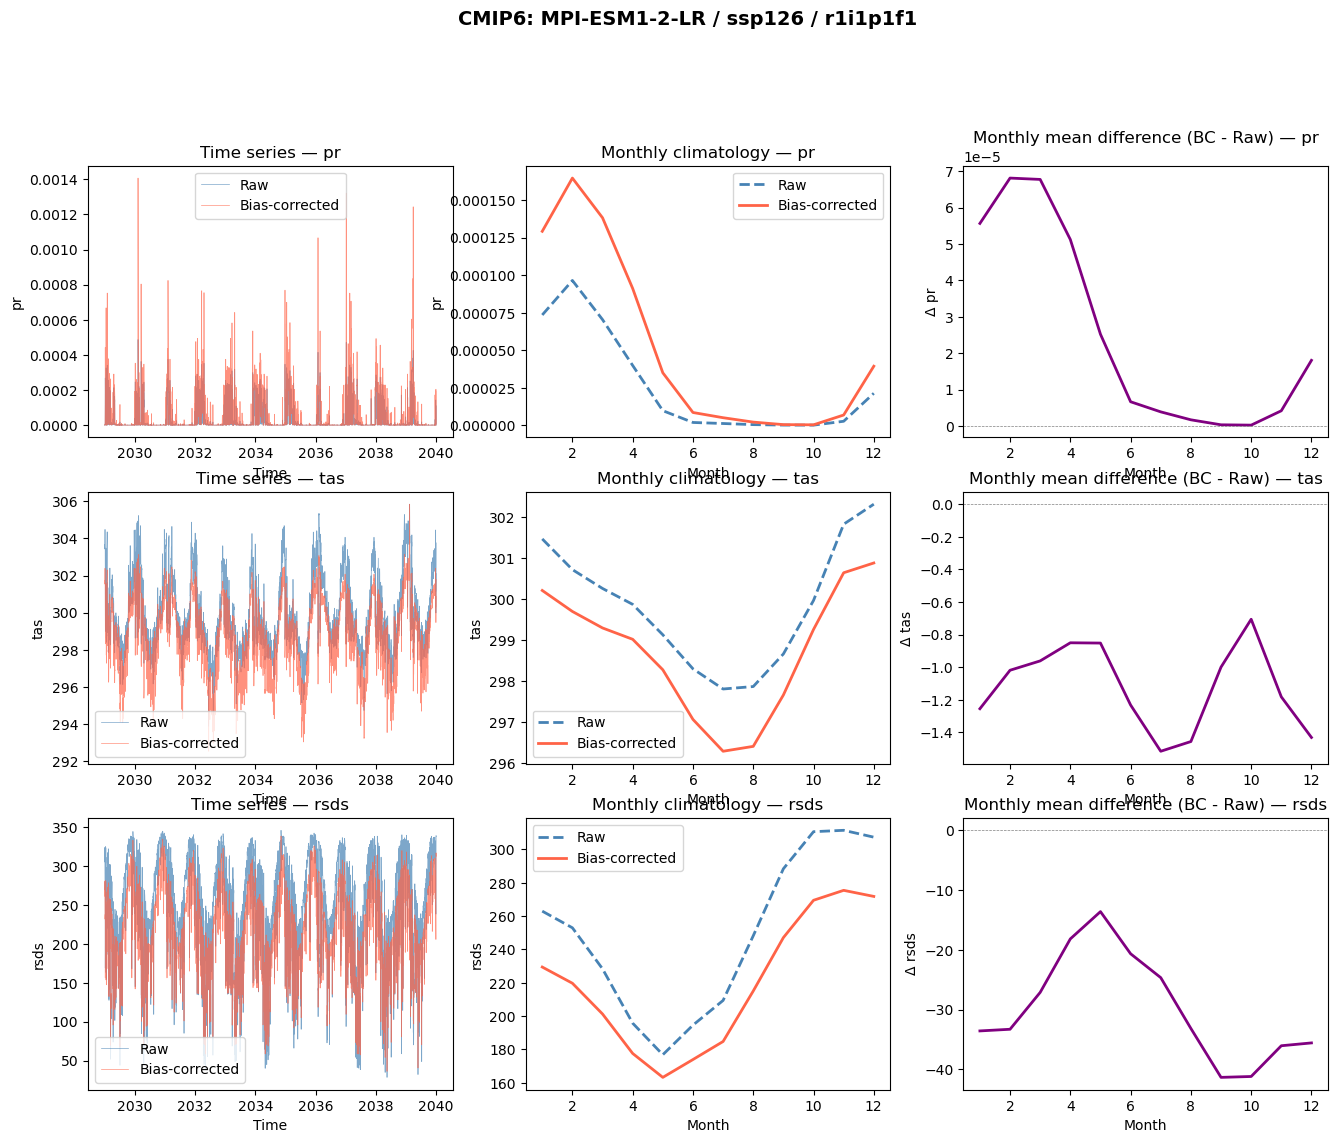

In [39]:
figures_dir_diff = Path(settings["figure_output"]) / "difference"
figures_dir_diff.mkdir(exist_ok=True, parents=True)
figures_dir_cdf = Path(settings["figure_output"]) / "cdf"
figures_dir_cdf.mkdir(exist_ok=True, parents=True)

# CMIP6 diagnostics — all combinations
for (dataset, experiment, ensemble), ds_bc in bc_results.items():
    plot_bias_correction_diff(
        ds_raw=cmip_future[(dataset, experiment, ensemble)],
        ds_corrected=ds_bc,
        title_suffix=f"CMIP6: {dataset} / {experiment} / {ensemble}",
        output_dir=figures_dir,
        name=f"CMIP6_{dataset}_{experiment}_{ensemble}",
    )
    
    plot_bias_correction_cdf(
        ds_raw=cmip_future[(dataset, experiment, ensemble)],
        ds_corrected=ds_bc,
        title_suffix=f"CMIP6: {dataset} / {experiment} / {ensemble}",
        output_dir=figures_dir_cdf,
        name=f"CMIP6_{dataset}_{experiment}_{ensemble}",
    )

Saved: figures/DestinE_SSP3-7.0_diff.png

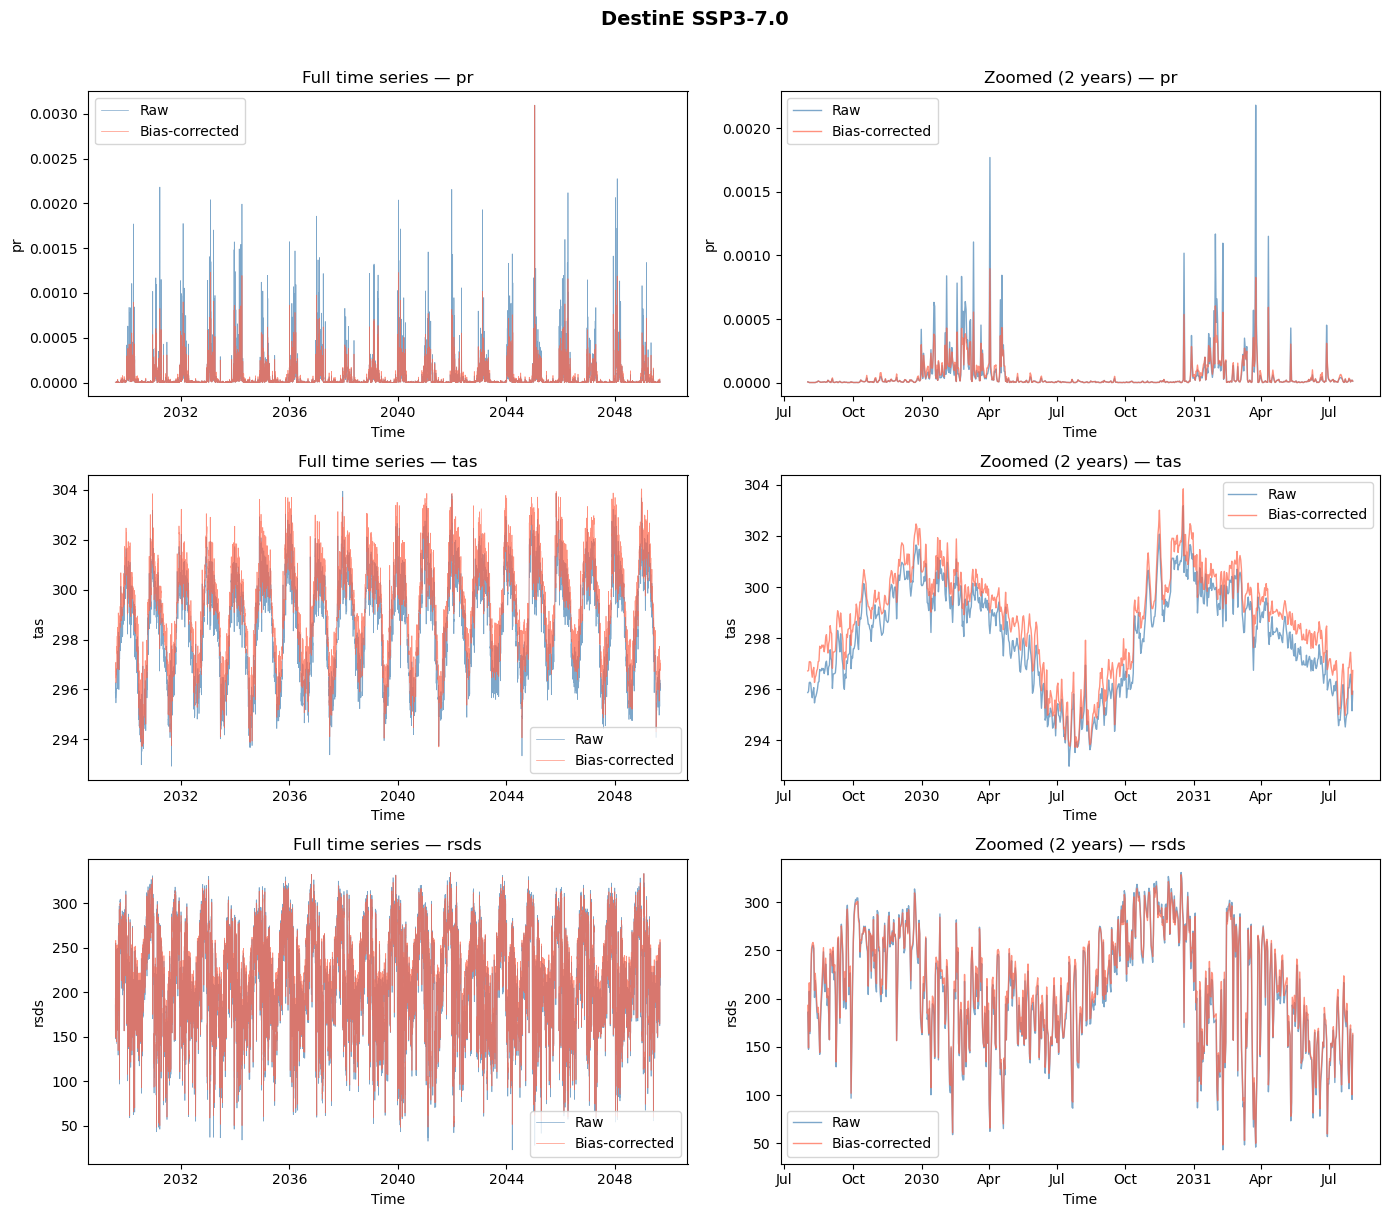

In [42]:
# DestinE diagnostics
plot_bias_correction_diff(
    ds_raw=ds_destine_future,
    ds_corrected=ds_destine_corrected,
    title_suffix="DestinE SSP3-7.0",
    output_dir=figures_dir,
    name="DestinE_SSP3-7.0",
)

plot_bias_correction_cdf(
    ds_raw=ds_destine_future,
    ds_corrected=ds_destine_corrected,
    title_suffix="DestinE SSP3-7.0",
    output_dir=figures_dir_cdf,
    name="DestinE_SSP3-7.0",
)

## Verify saved forcing

Reload one CMIP6 and the DestinE bias-corrected forcing as `LumpedMakkinkForcing` objects to confirm the files are valid and ready for use in step_3b.

In [ ]:
# Verify CMIP6 — load using the same pattern as step_3b, just pointing to bias_corrected/
first_key = next(iter(cmip_saved_paths))
dataset, experiment, ensemble = first_key
load_location = cmip_saved_paths[first_key]

cmip_bc_check = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
display(cmip_bc_check)

# Verify DestinE
destine_bc_check = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=destine_bc_dir)
display(destine_bc_check)

print("All bias-corrected forcing loaded successfully — ready for use in step_3b.")